# Lower Envelope of the Kernel Function

The single-spot kernel (truncated to $N=2$ harmonics) is:

$$k(\tau) = R_\Gamma(\tau) \left[ |c_0|^2 + 2|c_1|^2\cos(\omega_0\tau) + 2|c_2|^2\cos(2\omega_0\tau) \right]$$

The **upper envelope** is achieved when all cosines equal $+1$:

$$k_{\rm upper}(\tau) = R_\Gamma(\tau)\left[|c_0|^2 + 2|c_1|^2 + 2|c_2|^2\right]$$

The **lower envelope** (option 2: fundamental-only) uses the fact that when $\cos(\omega_0\tau)=-1$, we have $\cos(2\omega_0\tau)=+1$:

$$k_{\rm lower}(\tau) = R_\Gamma(\tau)\left[|c_0|^2 - 2|c_1|^2 + 2|c_2|^2\right]$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Compat: np.trapezoid was added in NumPy 2.0; older versions have np.trapz
if not hasattr(np, 'trapezoid'):
    np.trapezoid = np.trapz

## Helper functions

Reusing the envelope, visibility coefficient, and kernel functions from the paper's plotting scripts.

In [2]:
def alpha_trapezoid(t, ell, tau_s, alpha_max):
    """Trapezoidal envelope, centered at t=0."""
    abs_t = np.abs(t)
    L = ell / 2
    S = L + tau_s
    result = np.zeros_like(abs_t)
    result[abs_t <= L] = alpha_max
    ramp = (abs_t > L) & (abs_t <= S)
    result[ramp] = alpha_max * (S - abs_t[ramp]) / tau_s
    return result


def visibility_coefficients(inc, phi, n_harmonics):
    """Fourier coefficients c_n of the visibility function."""
    a0 = np.cos(inc) * np.sin(phi)
    a1 = np.sin(inc) * np.cos(phi)
    if np.abs(a0) >= a1:
        theta_vis = np.pi if a0 > 0 else 0.0
        if theta_vis == 0.0:
            return np.zeros(n_harmonics + 1)
    else:
        theta_vis = np.arccos(-a0 / a1)

    c = np.zeros(n_harmonics + 1)
    c[0] = (a0 * theta_vis + a1 * np.sin(theta_vis)) / np.pi
    c[1] = (a0 * np.sin(theta_vis)
            + a1 * (theta_vis + np.sin(theta_vis) * np.cos(theta_vis)) / 2) / np.pi
    for n in range(2, n_harmonics + 1):
        term1 = a0 * np.sin(n * theta_vis) / n
        term2 = a1 / 2 * (
            np.sin((n - 1) * theta_vis) / (n - 1)
            + np.sin((n + 1) * theta_vis) / (n + 1)
        )
        c[n] = (term1 + term2) / np.pi
    return c


def R_Gamma_numerical(tau_arr, t_grid, Gamma_grid):
    """Autocorrelation R_Gamma(tau) = int Gamma(s) Gamma(s+tau) ds."""
    R = np.empty_like(tau_arr)
    for i, tau_val in enumerate(tau_arr):
        Gamma_shifted = np.interp(t_grid + tau_val, t_grid, Gamma_grid,
                                  left=0.0, right=0.0)
        R[i] = np.trapezoid(Gamma_grid * Gamma_shifted, t_grid)
    return R

## Parameters and kernel computation

In [3]:
# Physical parameters
alpha_max = 0.1       # peak angular radius [rad]
ell = 15.0            # plateau duration [days]
tau_s = 3.0           # rise/decay timescale [days]
P_eq = 5.0            # rotation period [days]
inc = np.pi / 4       # stellar inclination (edge-on)
phi = np.pi / 4       # spot latitude (45 deg)
n_harmonics = 2

omega0 = 2 * np.pi / P_eq

# Compute visibility coefficients
cn = visibility_coefficients(inc, phi, n_harmonics)
print(f"c_0 = {cn[0]:.4f}")
print(f"c_1 = {cn[1]:.4f}")
print(f"c_2 = {cn[2]:.4f}")

# Envelope coefficients for upper/lower envelopes
coeff_upper = cn[0]**2 + 2 * cn[1]**2 + 2 * cn[2]**2
coeff_lower = cn[0]**2 - 2 * cn[1]**2 + 2 * cn[2]**2
print(f"\nUpper envelope coefficient: |c0|^2 + 2|c1|^2 + 2|c2|^2 = {coeff_upper:.4f}")
print(f"Lower envelope coefficient: |c0|^2 - 2|c1|^2 + 2|c2|^2 = {coeff_lower:.4f}")

c_0 = 0.5000
c_1 = 0.2500
c_2 = 0.0000

Upper envelope coefficient: |c0|^2 + 2|c1|^2 + 2|c2|^2 = 0.3750
Lower envelope coefficient: |c0|^2 - 2|c1|^2 + 2|c2|^2 = 0.1250


In [4]:
# Compute R_Gamma(tau) via numerical autocorrelation
t_margin = 8 * tau_s
t_grid = np.linspace(-ell / 2 - t_margin, ell / 2 + t_margin, 2**14)

env = alpha_trapezoid(t_grid, ell, tau_s, alpha_max)
Gamma = env**2

tau_max_plot = ell + 4 * tau_s
tau_arr = np.linspace(0, tau_max_plot, 1500)

R_Gamma = R_Gamma_numerical(tau_arr, t_grid, Gamma)
R_Gamma_norm = R_Gamma / R_Gamma[0]

# Kernel and envelopes
cosine_sum = cn[0]**2 + 2 * cn[1]**2 * np.cos(omega0 * tau_arr) \
                       + 2 * cn[2]**2 * np.cos(2 * omega0 * tau_arr)
k = R_Gamma_norm * cosine_sum
k_norm = k / k[0]

upper_env = R_Gamma_norm * coeff_upper / (coeff_upper)  # = R_Gamma_norm (normalized)
lower_env = R_Gamma_norm * coeff_lower / coeff_upper     # normalized by k(0)

print(f"Kernel computed over {len(tau_arr)} lag points, tau_max = {tau_max_plot:.1f} days")

Kernel computed over 1500 lag points, tau_max = 27.0 days


## Plot

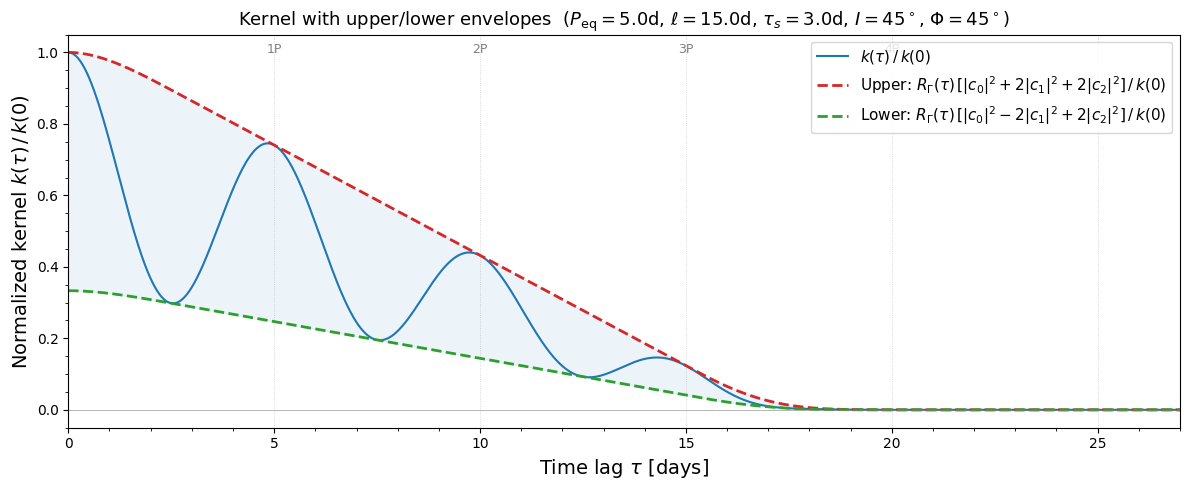

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(tau_arr, k_norm, color='C0', lw=1.5, label=r'$k(\tau)\,/\,k(0)$')
ax.plot(tau_arr, upper_env, color='C3', lw=2, ls='--',
        label=r'Upper: $R_\Gamma(\tau)\,[|c_0|^2 + 2|c_1|^2 + 2|c_2|^2]\,/\,k(0)$')
ax.plot(tau_arr, lower_env, color='C2', lw=2, ls='--',
        label=r'Lower: $R_\Gamma(\tau)\,[|c_0|^2 - 2|c_1|^2 + 2|c_2|^2]\,/\,k(0)$')
ax.fill_between(tau_arr, lower_env, upper_env, color='C0', alpha=0.08)

# Mark rotation period multiples
for n in range(1, int(tau_max_plot / P_eq) + 1):
    ax.axvline(n * P_eq, color='gray', ls=':', lw=0.6, alpha=0.4)
    if n <= 4:
        ax.text(n * P_eq, ax.get_ylim()[1] * 0.95, f'{n}P',
                ha='center', fontsize=9, color='gray')

ax.axhline(0, color='gray', ls='-', lw=0.4)
ax.set_xlabel(r'Time lag $\tau$ [days]', fontsize=14)
ax.set_ylabel(r'Normalized kernel $k(\tau)\,/\,k(0)$', fontsize=14)
ax.set_title(
    rf'Kernel with upper/lower envelopes  '
    rf'($P_{{\rm eq}}={P_eq}$d, $\ell={ell}$d, $\tau_s={tau_s}$d, '
    rf'$I={np.degrees(inc):.0f}^\circ$, $\Phi={np.degrees(phi):.0f}^\circ$)',
    fontsize=13)
ax.set_xlim(0, tau_max_plot)
ax.legend(fontsize=11, loc='upper right')
ax.minorticks_on()

fig.tight_layout()
plt.show()

## Verify: lower envelope touches the kernel at half-period troughs

At $\tau = (2m+1) \cdot P_{\rm eq}/2$ (odd half-periods), $\cos(\omega_0\tau) = -1$ and $\cos(2\omega_0\tau) = +1$, so the kernel should exactly equal the lower envelope.

In [6]:
# Check at odd half-periods
half_periods = np.arange(1, int(2 * tau_max_plot / P_eq), 2) * P_eq / 2
half_periods = half_periods[half_periods < tau_max_plot]

for hp in half_periods:
    idx = np.argmin(np.abs(tau_arr - hp))
    print(f"tau = {hp:6.2f}d (= {hp/P_eq:.1f} P):  "
          f"k/k(0) = {k_norm[idx]:+.6f},  "
          f"lower_env = {lower_env[idx]:+.6f},  "
          f"diff = {k_norm[idx] - lower_env[idx]:.2e}")

tau =   2.50d (= 0.5 P):  k/k(0) = -0.004181,  lower_env = -0.004182,  diff = 1.34e-06
tau =   7.50d (= 1.5 P):  k/k(0) = -0.002740,  lower_env = -0.002743,  diff = 3.19e-06
tau =  12.50d (= 2.5 P):  k/k(0) = -0.001298,  lower_env = -0.001298,  diff = 3.43e-09
tau =  17.50d (= 3.5 P):  k/k(0) = -0.000061,  lower_env = -0.000061,  diff = 8.58e-08
tau =  22.50d (= 4.5 P):  k/k(0) = -0.000000,  lower_env = -0.000000,  diff = 0.00e+00
